In [6]:
import pickle
import numpy as np



time_frame = pickle.load(open("time.pickle","rb"))
time_frame.shape

wb_fluxes = pickle.load(open("wb_fluxes.pickle","rb"))
wb_fluxes.shape


19500


(147, 19500)

In [8]:
norm_time_frame = time_frame - int(time_frame[0])

In [9]:
norm_time_frame

array([0.67590709, 0.67592303, 0.67593898, ..., 0.98675594, 0.98677188,
       0.98678783])

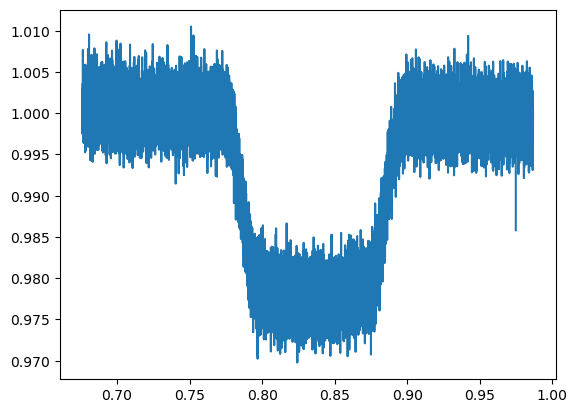

In [10]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(norm_time_frame,wb_fluxes[50])
plt.show()

In [5]:
import time 
  
  
def timeis(func): 
    '''Decorator that reports the execution time.'''
  
    def wrap(*args, **kwargs): 
        start = time.time() 
        result = func(*args, **kwargs) 
        end = time.time() 
          
        print(func.__name__, end-start) 
        return result 
    return wrap 

@timeis
def countdown(n): 
    '''Counts down'''
    while n > 0: 
        n -= 1

countdown(5)

countdown 2.1457672119140625e-06


In [ ]:
import batman
def wrapper(func, *args, **kwargs):
    def wrapped():
        func(*args, **kwargs)
        return func
    return wrapped

@wrapper
def bat(times, rp, u):
    params = batman.TransitParams()       #object to store transit parameters
    params.t0 = 0.8356471737                      #time of inferior conjunction
    params.per = 4.0552842518                       #orbital period
    params.rp = rp                      #planet radius (in units of stellar radii)
    params.a = 11.3904973685                    #semi-major axis (in units of stellar radii)
    params.inc = 87.7369030491272                      #orbital inclination (in degrees)
    params.ecc = 0                       #eccentricity
    params.w = 90                        #longitude of periastron (in degrees)
    params.limb_dark = "quadratic"        #limb darkening model
    params.u = u

    m = batman.TransitModel(params, times)
    flux = m.light_curve(params)
    return flux

